In [11]:
import math, sys
from pathlib import Path
sys.path.append('../')
sys.path.append('../src')
from tools.propose_batch.bo import load_bo_history, build_bo_optimizer, _pbounds
import yaml, numpy as np, matplotlib.pyplot as plt

In [12]:
policy = yaml.safe_load(open("../policy/proposer_policy.yaml"))
history = load_bo_history("input.W7-X_without_coil_ripple_beta0p05_d23p4_tm",
                          Path("../submissions"))
bounds = _pbounds(policy)
bo = build_bo_optimizer(history, bounds, seed=42)

In [13]:
# Fit the GP explicitly (register() stores data but doesn't train the model)
bo._gp.fit(bo._space.params, bo._space.target)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","WrappedKernel...ale=1, nu=2.5)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-06
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",5
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

In [14]:
# 2-D slice: length_threshold vs cc_threshold (all other dims held at their median)
n = 60
dim_order = list(bounds.keys())  # explicit ordering to match _space.params columns
lx = np.linspace(*bounds["log_length_threshold"], n)
ly = np.linspace(*bounds["log_cc_threshold"], n)
median = {k: (lo + hi) / 2 for k, (lo, hi) in bounds.items()}
X, Y = np.meshgrid(lx, ly)
pts = []
for x, y in zip(X.ravel(), Y.ravel()):
    p = dict(median)
    p["log_length_threshold"] = x
    p["log_cc_threshold"] = y
    pts.append([p[k] for k in dim_order])  # order must match dim_order
Z = bo._gp.predict(pts).reshape(n, n)

Saved /tmp/gp_posterior_w7x.png


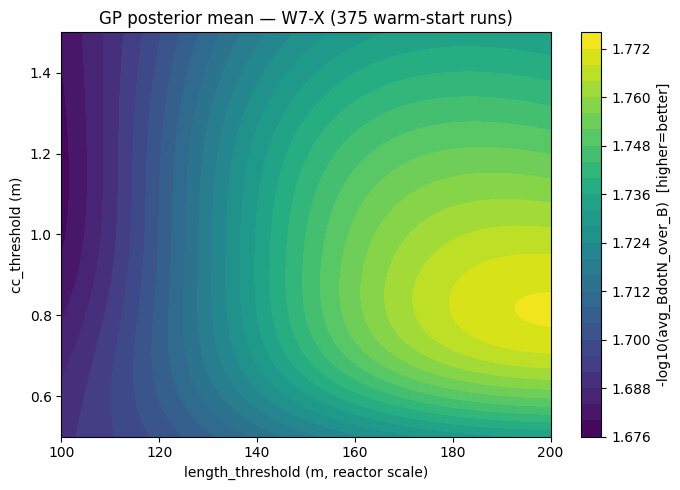

In [15]:
plt.figure(figsize=(7,5))
plt.contourf(np.exp(X), np.exp(Y), Z, levels=30, cmap="viridis")
plt.colorbar(label="-log10(avg_BdotN_over_B)  [higher=better]")
plt.xlabel("length_threshold (m, reactor scale)"); plt.ylabel("cc_threshold (m)")
plt.title(f"GP posterior mean — W7-X ({len(history)} warm-start runs)")
plt.tight_layout(); plt.savefig("/tmp/gp_posterior_w7x.png", dpi=150)
print("Saved /tmp/gp_posterior_w7x.png")

Loaded 1081 feasible QA runs


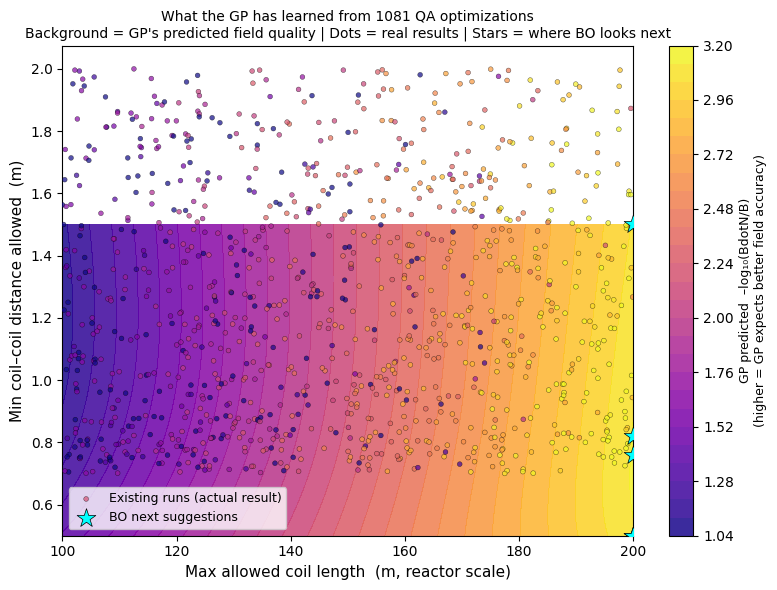

Saved /tmp/gp_landscape_qa.png


In [16]:
import math, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml, sys
sys.path.append('../'); sys.path.append('../src')
from tools.propose_batch.bo import load_bo_history, build_bo_optimizer, _pbounds

# Use QA surface — richest dataset (4,519 runs, ~450 feasible)
surface = "input.LandremanPaul2021_QA"
policy_qa = yaml.safe_load(open("../policy/proposer_policy.yaml"))
# Override surface in policy so _pbounds reads the right ranges
policy_qa["exploration"]["surfaces"] = [surface]

history = load_bo_history(surface, Path("../submissions"))
bounds = _pbounds(policy_qa)
dim_order = list(bounds.keys())
print(f"Loaded {len(history)} feasible QA runs")

# Fit GP
bo = build_bo_optimizer(history, bounds, seed=42)
bo._gp.fit(bo._space.params, bo._space.target)

# --- GP background: length_threshold vs cc_threshold (other dims at median) ---
n = 80
lx = np.linspace(*bounds["log_length_threshold"], n)
ly = np.linspace(*bounds["log_cc_threshold"], n)
median = {k: (lo + hi) / 2 for k, (lo, hi) in bounds.items()}
Xg, Yg = np.meshgrid(lx, ly)
pts = []
for x, y in zip(Xg.ravel(), Yg.ravel()):
    p = dict(median); p["log_length_threshold"] = x; p["log_cc_threshold"] = y
    pts.append([p[k] for k in dim_order])
Z = bo._gp.predict(pts).reshape(n, n)

# --- Actual run positions in the same 2D slice ---
run_l  = [r["params"]["log_length_threshold"] for r in history]
run_cc = [r["params"]["log_cc_threshold"]      for r in history]
run_t  = [r["target"] for r in history]   # -log10(avg_BdotN_over_B)

# --- BO next suggestions (with hallucination so they're spread out) ---
suggestions = []
for _ in range(6):
    raw = bo.suggest()
    suggestions.append(raw)
    pred = float(bo._gp.predict([[raw[k] for k in dim_order]])[0])
    bo.register(params=raw, target=pred)

sug_l  = [math.exp(s["log_length_threshold"]) for s in suggestions]
sug_cc = [math.exp(s["log_cc_threshold"])      for s in suggestions]

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

cf = ax.contourf(np.exp(Xg), np.exp(Yg), Z, levels=30, cmap="plasma", alpha=0.85)
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label("GP predicted  –log₁₀(BdotN/B)\n(higher = GP expects better field accuracy)", fontsize=9)

# Actual runs — same color scale so dots sit naturally on the background
sc = ax.scatter(np.exp(run_l), np.exp(run_cc), c=run_t,
                cmap="plasma", vmin=Z.min(), vmax=Z.max(),
                s=12, alpha=0.7, edgecolors="k", linewidths=0.3,
                zorder=3, label="Existing runs (actual result)")

# BO-suggested next points
ax.scatter(sug_l, sug_cc, c="cyan", s=200, marker="*", zorder=5,
           edgecolors="k", linewidths=0.5,
           label="BO next suggestions")

ax.set_xlabel("Max allowed coil length  (m, reactor scale)", fontsize=11)
ax.set_ylabel("Min coil–coil distance allowed  (m)", fontsize=11)
ax.set_title(
    f"What the GP has learned from {len(history)} QA optimizations\n"
    "Background = GP's predicted field quality | Dots = real results | Stars = where BO looks next",
    fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("/tmp/gp_landscape_qa.png", dpi=150)
plt.show()
print("Saved /tmp/gp_landscape_qa.png")